# **Projeto: Informação Georreferenciada**
Fernando Bichuette e Thomas Bekhor


## Problemática a ser resolvida

Este projeto tem como objetivo investigar a eficiência da vigilância e fiscalização do desmatamento e das queimadas na Amazônia Legal. Através da análise de mapas de desmatamento e queimadas, identificamos as áreas mais afetadas por esses fenômenos. Além disso, ao mapear a localização dos postos do IBAMA e das infrações detectadas, podemos entender melhor as áreas de maior atuação efetiva das autoridades. Ao final, buscamos responder à seguinte pergunta: O IBAMA está presente nos locais com mais casos de desmatamento e queimadas? Nos locais que sim, há uma boa fiscalização?

## Apresentação dos dados

Os seguintes dados foram coletados, com suas respectivas fontes. O link abaixo tem todos os dados baixados:

https://alinsperedu-my.sharepoint.com/:f:/g/personal/thomasb2_al_insper_edu_br/EsN_kEJgaM1KgxinKpH2BYkBsLnJb8Jx0_Jr3zPn1X2lcw?e=ldJZ7T

Fonte:

1) Dados de desmatamento de 2016 a 2022 (Inpe).

- https://terrabrasilis.dpi.inpe.br/downloads/

2) Dados de focos de incêndio de 2016 a 2022 (Inpe).

- https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref/

3) Postos do Ibama na Amazônia Legal (Ibama).

- https://dadosabertos.ibama.gov.br/dataset/unidades-ibama

4) Infrações criminais ambientais no bioma da Amazônia de 2016 a 2022 (Ibama).

- https://dadosabertos.ibama.gov.br/dataset/fiscalizacao-auto-de-infracao

## Formatação Geógrafica


Importando as bibliotecas

In [ ]:
!pip install contextily --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 66.2 MB/s eta 0:00:00


In [ ]:
!pip install ipywidgets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s eta 0:00:00


In [ ]:
!pip install esda libpysal --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 54.0 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np
import libpysal as ps
import seaborn as sns
from shapely.geometry import Point
from shapely.geometry import box
from ipywidgets import interact, IntSlider
from esda.moran import Moran


Carregando os arquivos necessários

In [ ]:
infracoes= pd.read_excel('infracoes_16a22.xlsx')
incendio= pd.read_excel('incendio16a22.xlsx')
limites = gpd.read_file('brazilian_legal_amazon.shp')
muni=gpd.read_file("municipalities_legal_amazon.shp")
desmat=gpd.read_file("deter-amz-deter-public.shp")
ibama = gpd.read_file("adm_edif_pub_civil_ibama_p.shp")

### Infrações


A base de dados abaixo mostra todas as infrações de desmatamento e queimadas registradas por entidades entre 2016 e 2022.

In [ ]:
infracoes.head()

,SEQ_AUTO_INFRACAO,TIPO_AUTO,TIPO_MULTA,VAL_AUTO_INFRACAO,GRAVIDADE_INFRACAO,MOTIVACAO_CONDUTA,EFEITO_MEIO_AMBIENTE,EFEITO_SAUDE_PUBLICA,Unnamed: 8,DAT_HORA_AUTO_INFRACAO,...,DT_FIM_ATO_INEQUIVOCO,COD_MUNICIPIO,MUNICIPIO,UF,INFRACAO_AREA,CLASSIFICACAO_AREA,NUM_LONGITUDE_AUTO,NUM_LATITUDE_AUTO,DS_WKT,DS_BIOMAS_ATINGIDOS
0,1748737,Multa simples,Fechada,"50000,00",NaN,NaN,NaN,NaN,NaN,2016-08-30 20:50:00,...,NaN,1302405,LABREA,AM,Desmatamento,NaN,"-64,997778","-7,340556",POINT (-64.997778 -7.340556),Amazonia
1,1748742,Multa simples,Fechada,"15000,00",NaN,NaN,NaN,NaN,NaN,2016-09-02 17:08:00,...,NaN,1300904,CANUTAMA,AM,Desmatamento,NaN,"-64,386111","-6,540278",POINT (-64.386111 -6.540278),"Amazonia, Costeiro e Marinho"
2,1748745,Multa simples,Fechada,"1000,00",NaN,Intencional,NaN,NaN,NaN,2016-10-27 10:46:00,...,NaN,1302603,MANAUS,AM,Desmatamento,NaN,"-59,980556","-3,134722",POINT (-59.980556 -3.134722),"Amazonia, Costeiro e Marinho"
3,1748767,Multa simples,Aberta,"1000,00",NaN,Intencional,NaN,NaN,NaN,2016-10-27 13:51:00,...,NaN,1302603,MANAUS,AM,Desmatamento,NaN,"-58,996944","-3,134167",POINT (-58.996944 -3.134167),"Amazonia, Cerrado, Costeiro e Marinho"
4,1780139,Multa simples,Aberta,"311500,00",Média,NaN,NaN,NaN,NaN,2016-05-05 09:44:00,...,NaN,5220207,SAO MIGUEL DO ARAGUAIA,GO,Desmatamento,Outras áreas,"-50,1675","-13,269444",POINT (-50.1675 -13.269444),Amazonia


In [ ]:
infracoes.columns

Index(['SEQ_AUTO_INFRACAO', 'TIPO_AUTO', 'TIPO_MULTA', 'VAL_AUTO_INFRACAO',
       'GRAVIDADE_INFRACAO', 'MOTIVACAO_CONDUTA', 'EFEITO_MEIO_AMBIENTE',
       'EFEITO_SAUDE_PUBLICA', 'Unnamed: 8', 'DAT_HORA_AUTO_INFRACAO',
       'DAT_CIENCIA_AUTUACAO', 'DT_FATO_INFRACIONAL', 'DIF_TEMPO', 'ANO',
       'DT_INICIO_ATO_INEQUIVOCO', 'DT_FIM_ATO_INEQUIVOCO', 'COD_MUNICIPIO',
       'MUNICIPIO', 'UF', 'INFRACAO_AREA', 'CLASSIFICACAO_AREA',
       'NUM_LONGITUDE_AUTO', 'NUM_LATITUDE_AUTO', 'DS_WKT',
       'DS_BIOMAS_ATINGIDOS'],
      dtype='object')

Transformando para o formato GeoPandas

In [ ]:
infracoes['geometry'] = gpd.GeoSeries.from_wkt(infracoes['DS_WKT'])
infracoes_gpd = gpd.GeoDataFrame(infracoes, geometry='geometry')

In [ ]:
infracoes_gpd

,SEQ_AUTO_INFRACAO,TIPO_AUTO,TIPO_MULTA,VAL_AUTO_INFRACAO,GRAVIDADE_INFRACAO,MOTIVACAO_CONDUTA,EFEITO_MEIO_AMBIENTE,EFEITO_SAUDE_PUBLICA,Unnamed: 8,DAT_HORA_AUTO_INFRACAO,...,COD_MUNICIPIO,MUNICIPIO,UF,INFRACAO_AREA,CLASSIFICACAO_AREA,NUM_LONGITUDE_AUTO,NUM_LATITUDE_AUTO,DS_WKT,DS_BIOMAS_ATINGIDOS,geometry
0,1748737,Multa simples,Fechada,"50000,00",NaN,NaN,NaN,NaN,NaN,2016-08-30 20:50:00,...,1302405,LABREA,AM,Desmatamento,NaN,"-64,997778","-7,340556",POINT (-64.997778 -7.340556),Amazonia,POINT (-64.99778 -7.34056)
1,1748742,Multa simples,Fechada,"15000,00",NaN,NaN,NaN,NaN,NaN,2016-09-02 17:08:00,...,1300904,CANUTAMA,AM,Desmatamento,NaN,"-64,386111","-6,540278",POINT (-64.386111 -6.540278),"Amazonia, Costeiro e Marinho",POINT (-64.38611 -6.54028)
2,1748745,Multa simples,Fechada,"1000,00",NaN,Intencional,NaN,NaN,NaN,2016-10-27 10:46:00,...,1302603,MANAUS,AM,Desmatamento,NaN,"-59,980556","-3,134722",POINT (-59.980556 -3.134722),"Amazonia, Costeiro e Marinho",POINT (-59.98056 -3.13472)
3,1748767,Multa simples,Aberta,"1000,00",NaN,Intencional,NaN,NaN,NaN,2016-10-27 13:51:00,...,1302603,MANAUS,AM,Desmatamento,NaN,"-58,996944","-3,134167",POINT (-58.996944 -3.134167),"Amazonia, Cerrado, Costeiro e Marinho",POINT (-58.99694 -3.13417)
4,1780139,Multa simples,Aberta,"311500,00",Média,NaN,NaN,NaN,NaN,2016-05-05 09:44:00,...,5220207,SAO MIGUEL DO ARAGUAIA,GO,Desmatamento,Outras áreas,"-50,1675","-13,269444",POINT (-50.1675 -13.269444),Amazonia,POINT (-50.1675 -13.26944)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20420,2089752,Multa simples,Fechada,185000,NaN,Intencional,Significativa,Potencial,NaN,2022-09-16 11:19:36,...,5106158,NOVA BANDEIRANTES,MT,Desmatamento,Reserva Legal,-57.821639,-9.567904,POINT (-57.82163888889 -9.56790361112),Amazonia,POINT (-57.82164 -9.5679)
20421,2091195,Multa simples,Fechada,7308.9,NaN,NaN,NaN,NaN,NaN,2022-03-10 07:30:00,...,5103403,CUIABA,MT,Desmatamento,Outras Ã¡reas,-56.060833,-15.580278,POINT (-56.06083333333 -15.58027777778),Amazonia,POINT (-56.06083 -15.58028)
20422,2093844,Multa simples,Fechada,4600000,NaN,Intencional,Significativa,Potencial,NaN,2022-08-09 12:59:38,...,1507805,SENADOR JOSE PORFIRIO,PA,Desmatamento,AmazÃ´nia Legal,-52.070937,-3.908778,POINT (-52.07093694445 -3.90877805556),Amazonia,POINT (-52.07094 -3.90878)
20423,2102728,Multa simples,Fechada,4054950,NaN,Intencional,Significativa,Significativa,NaN,2022-09-13 17:34:14,...,5106158,NOVA BANDEIRANTES,MT,Desmatamento,AmazÃ´nia Legal,-57.978311,-9.504378,POINT (-57.97831111112 -9.50437777778),Amazonia,POINT (-57.97831 -9.50438)


<ipython-input-11-c2036b6cee09>:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  infracoes_within_limites = infracoes_gpd[infracoes_gpd.within(limites.unary_union)]


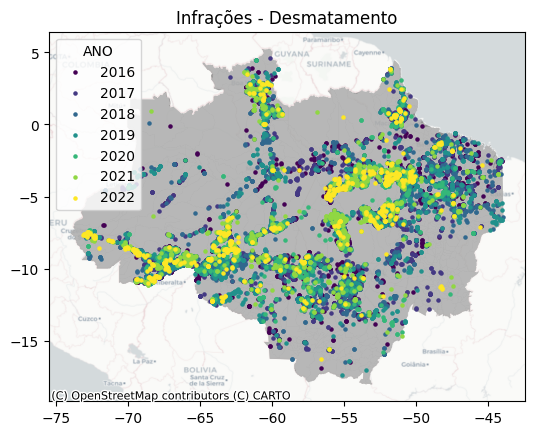

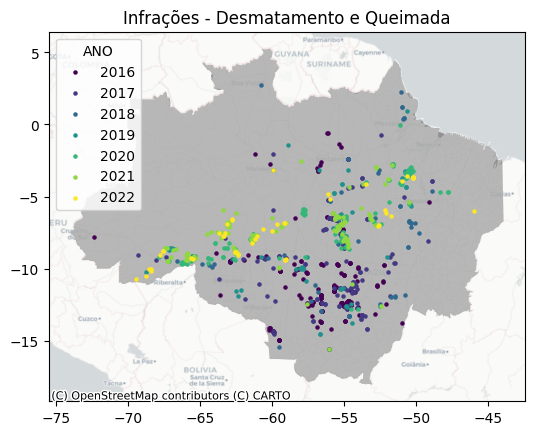

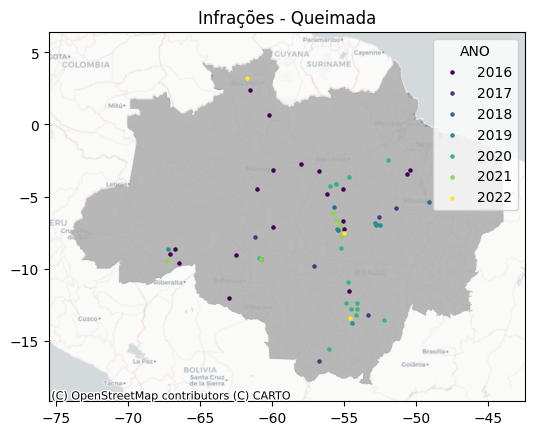

In [ ]:
# Filtrar infracoes_gpd para incluir apenas pontos dentro dos limites
infracoes_within_limites = infracoes_gpd[infracoes_gpd.within(limites.unary_union)]

# Identificar as categorias únicas de infrações
unique_infracoes = infracoes_within_limites['INFRACAO_AREA'].unique()

# Loop para criar um gráfico para cada tipo de infração
for infracao in unique_infracoes:
    # Filtrar dados para a categoria de infração atual
    data_by_infracao = infracoes_within_limites[infracoes_within_limites['INFRACAO_AREA'] == infracao]

    # Configurar o plot para a infração atual
    fig, ax = plt.subplots()
    limites.plot(ax=ax, color='grey', alpha=0.8)
    muni.plot(ax=ax, color='white', alpha=0.3)
    # Definir uma paleta de cores para os anos dentro da categoria de infração atual
    unique_years = data_by_infracao['ANO'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_years)))

    # Plotar cada ano com uma cor diferente para a infração atual
    for color, year in zip(colors, unique_years):
        data_by_year = data_by_infracao[data_by_infracao['ANO'] == year]
        data_by_year.plot(ax=ax, color=color, markersize=5, label=str(year))

    # Adicionar o basemap e configurar o layout
    ctx.add_basemap(ax, crs=limites.crs.to_string(), source=ctx.providers.CartoDB.Positron)
    plt.legend(title="ANO")
    plt.title(f"Infrações - {infracao}")
    plt.show()

Vamos visualizar a quantidade de ocorrencias por ano e tipo.

In [ ]:
# Agrupar os dados por ano e categoria de infração, contando o número de ocorrências em cada grupo
ocorrencias_por_ano_categoria = (
    infracoes_within_limites
    .groupby(['ANO', 'INFRACAO_AREA'])
    .size()
    .reset_index(name='Contagem')
)

# Exibir o resultado
print(ocorrencias_por_ano_categoria)


     ANO            INFRACAO_AREA  Contagem
0   2016             Desmatamento      4170
1   2016  Desmatamento e Queimada       208
2   2016                 Queimada        19
3   2017             Desmatamento      4015
4   2017  Desmatamento e Queimada       140
5   2017                 Queimada         6
6   2018             Desmatamento      3560
7   2018  Desmatamento e Queimada        64
8   2018                 Queimada         3
9   2019             Desmatamento      3466
10  2019  Desmatamento e Queimada        69
11  2019                 Queimada        10
12  2020             Desmatamento      1239
13  2020  Desmatamento e Queimada       124
14  2020                 Queimada        15
15  2021             Desmatamento      1411
16  2021  Desmatamento e Queimada       151
17  2021                 Queimada         6
18  2022             Desmatamento       651
19  2022  Desmatamento e Queimada        50
20  2022                 Queimada         3


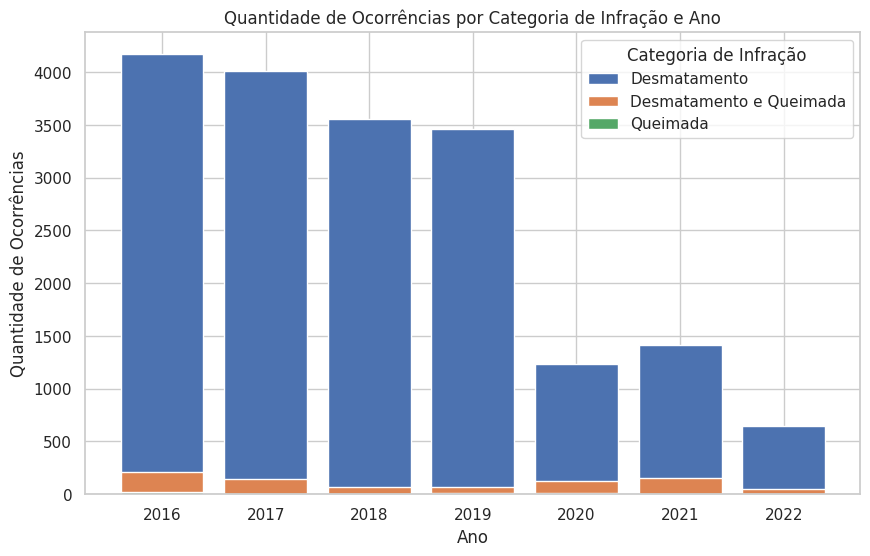

In [ ]:
# Configurar o estilo do gráfico
sns.set(style="whitegrid")

# Agrupar e contar as ocorrências por ano e categoria de infração
ocorrencias_por_ano_categoria = (
    infracoes_within_limites
    .groupby(['ANO', 'INFRACAO_AREA'])
    .size()
    .reset_index(name='Contagem')
)

# Configurar o gráfico
plt.figure(figsize=(10, 6))

# Usar gráfico de barras empilhadas para mostrar as quantidades por categoria e ano
for categoria in ocorrencias_por_ano_categoria['INFRACAO_AREA'].unique():
    # Filtrar dados por categoria
    data_by_category = ocorrencias_por_ano_categoria[ocorrencias_por_ano_categoria['INFRACAO_AREA'] == categoria]
    # Plotar cada categoria como uma barra empilhada
    plt.bar(data_by_category['ANO'],
            data_by_category['Contagem'],
            label=categoria)

# Personalizar o gráfico
plt.xlabel("Ano")
plt.ylabel("Quantidade de Ocorrências")
plt.title("Quantidade de Ocorrências por Categoria de Infração e Ano")
plt.legend(title="Categoria de Infração")
plt.show()

In [ ]:
# Agrupar as infrações por município e contar o número de ocorrências em cada um
ocorrencias_por_municipio = (
    infracoes_gpd
    .groupby('MUNICIPIO')
    .size()
    .reset_index(name='Contagem')
    .sort_values(by='Contagem', ascending=False)
)

# Exibir os municípios com o maior número de infrações
top_municipios = ocorrencias_por_municipio.head(10)
print("Municípios com maior número de infrações:")
print(top_municipios)


Municípios com maior número de infrações:
              MUNICIPIO  Contagem
80                BELEM       895
483         PORTO VELHO       869
314              LABREA       824
339              MANAUS       736
557  SAO FELIX DO XINGU       649
21             ALTAMIRA       586
421              PACAJA       442
410      NOVO PROGRESSO       403
515        RORAINOPOLIS       388
45                 APUI       348


#Ibama amazonia legal

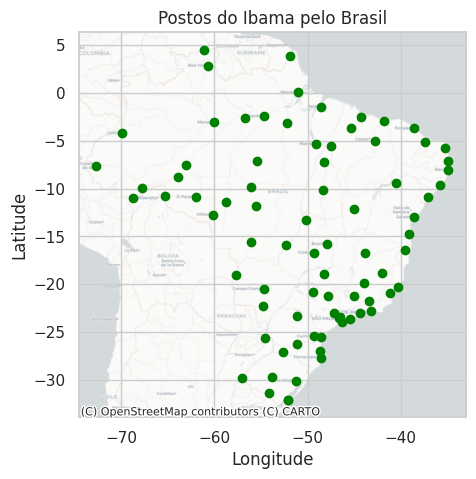

In [ ]:
ibama = gpd.read_file("adm_edif_pub_civil_ibama_p.shp")
fig, ax = plt.subplots(figsize=(10,5))

ibama.plot(ax = ax, color='green')
ctx.add_basemap(ax, crs=limites.crs.to_string(), source=ctx.providers.CartoDB.Positron)
plt.title("Postos do Ibama pelo Brasil")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Desmatamento

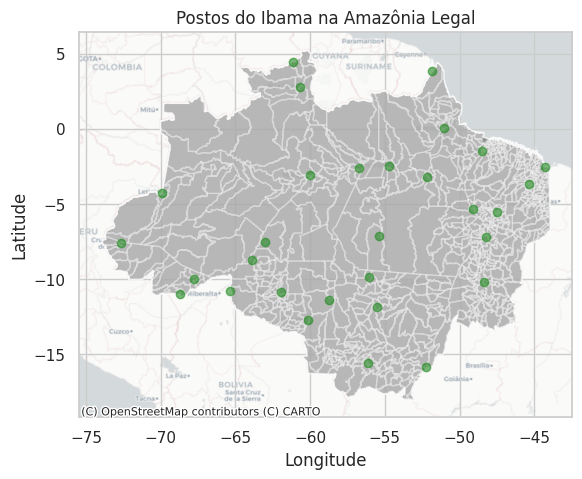

In [ ]:
# Filtrando para os estados da Amazônia Legal

estados_amazonia_legal = ['AC', 'AP', 'AM', 'MA', 'MT', 'PA', 'RO', 'RR', 'TO']

ibama_amazonia_legal = ibama[ibama['estado'].isin(estados_amazonia_legal)]

fig, ax = plt.subplots(figsize=(10,5))
limites.plot(ax=ax, color='grey', label='Limites', alpha=0.8)
muni.plot(ax=ax, color='white', alpha=0.3, label='Municípios')
ibama_amazonia_legal.plot(ax=ax, color='forestgreen', alpha=0.6, label='Operações IBAMA')
ctx.add_basemap(ax, crs=limites.crs.to_string(), source=ctx.providers.CartoDB.Positron)

plt.title("Postos do Ibama na Amazônia Legal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
print(ibama_amazonia_legal.crs)
print(limites.crs)
print(muni.crs)


EPSG:4674
EPSG:4674
EPSG:4674


# Queimadas

In [ ]:
incendio.head()

,id_bdq,foco_id,lat,lon,data_pas,pais,estado,municipio,bioma
0,191216016,86c9d5d2-5aba-11e8-911c-28924ad12c5c,3.887,-60.033,2016-01-02 17:20:00,Brasil,RORAIMA,NORMANDIA,Amazônia
1,191216017,86c9d5d3-5aba-11e8-911c-28924ad12c5c,3.696,-61.048,2016-01-02 17:20:00,Brasil,RORAIMA,AMAJARI,Amazônia
2,191216018,86c9d5d4-5aba-11e8-911c-28924ad12c5c,3.694,-61.061,2016-01-02 17:20:00,Brasil,RORAIMA,AMAJARI,Amazônia
3,191216019,86c9d5d5-5aba-11e8-911c-28924ad12c5c,0.801,-59.467,2016-01-02 17:20:00,Brasil,RORAIMA,CAROEBE,Amazônia
4,191216023,86c9d5d6-5aba-11e8-911c-28924ad12c5c,0.803,-59.456,2016-01-02 17:20:00,Brasil,RORAIMA,CAROEBE,Amazônia


In [ ]:
#from shapely.geometry import Point

# Criar uma coluna 'geometry' usando latitude e longitude
incendio['geometry'] = gpd.points_from_xy(incendio['lon'], incendio['lat'])

# Converter o DataFrame do Pandas em um GeoDataFrame usando a coluna 'geometry'
incendio_gdf = gpd.GeoDataFrame(incendio, geometry='geometry')
incendio_gdf.set_crs(epsg=4326, inplace=True)

# Exibir o GeoDataFrame com a nova coluna de geometria
print(incendio_gdf.head())


      id_bdq                               foco_id    lat     lon  \
0  191216016  86c9d5d2-5aba-11e8-911c-28924ad12c5c  3.887 -60.033   
1  191216017  86c9d5d3-5aba-11e8-911c-28924ad12c5c  3.696 -61.048   
2  191216018  86c9d5d4-5aba-11e8-911c-28924ad12c5c  3.694 -61.061   
3  191216019  86c9d5d5-5aba-11e8-911c-28924ad12c5c  0.801 -59.467   
4  191216023  86c9d5d6-5aba-11e8-911c-28924ad12c5c  0.803 -59.456   

              data_pas    pais   estado  municipio     bioma  \
0  2016-01-02 17:20:00  Brasil  RORAIMA  NORMANDIA  Amazônia   
1  2016-01-02 17:20:00  Brasil  RORAIMA    AMAJARI  Amazônia   
2  2016-01-02 17:20:00  Brasil  RORAIMA    AMAJARI  Amazônia   
3  2016-01-02 17:20:00  Brasil  RORAIMA    CAROEBE  Amazônia   
4  2016-01-02 17:20:00  Brasil  RORAIMA    CAROEBE  Amazônia   

                geometry  
0  POINT (-60.033 3.887)  
1  POINT (-61.048 3.696)  
2  POINT (-61.061 3.694)  
3  POINT (-59.467 0.801)  
4  POINT (-59.456 0.803)  


In [ ]:
# Garantir que a coluna data_pas está no formato datetime
incendio_gdf['data_pas'] = pd.to_datetime(incendio_gdf['data_pas'], errors='coerce')

# Criar a coluna 'ANO' extraindo o ano de 'data_pas'
incendio_gdf['ANO'] = incendio_gdf['data_pas'].dt.year

# Exibir o GeoDataFrame com a nova coluna 'ANO'
incendio_gdf

,id_bdq,foco_id,lat,lon,data_pas,pais,estado,municipio,bioma,geometry,ANO
0,191216016,86c9d5d2-5aba-11e8-911c-28924ad12c5c,3.88700,-60.03300,2016-01-02 17:20:00,Brasil,RORAIMA,NORMANDIA,Amazônia,POINT (-60.033 3.887),2016
1,191216017,86c9d5d3-5aba-11e8-911c-28924ad12c5c,3.69600,-61.04800,2016-01-02 17:20:00,Brasil,RORAIMA,AMAJARI,Amazônia,POINT (-61.048 3.696),2016
2,191216018,86c9d5d4-5aba-11e8-911c-28924ad12c5c,3.69400,-61.06100,2016-01-02 17:20:00,Brasil,RORAIMA,AMAJARI,Amazônia,POINT (-61.061 3.694),2016
3,191216019,86c9d5d5-5aba-11e8-911c-28924ad12c5c,0.80100,-59.46700,2016-01-02 17:20:00,Brasil,RORAIMA,CAROEBE,Amazônia,POINT (-59.467 0.801),2016
4,191216023,86c9d5d6-5aba-11e8-911c-28924ad12c5c,0.80300,-59.45600,2016-01-02 17:20:00,Brasil,RORAIMA,CAROEBE,Amazônia,POINT (-59.456 0.803),2016
...,...,...,...,...,...,...,...,...,...,...,...
646000,1614775852,c5db64a0-652c-39ee-a77d-ebd5aa636784,4.28665,-60.67235,2022-12-31 17:30:00,Brasil,RORAIMA,PACARAIMA,Amazônia,POINT (-60.67235 4.28665),2022
646001,1614775854,e7bff21d-2f4b-3327-a815-5f01bad1b7a6,4.28828,-60.66155,2022-12-31 17:30:00,Brasil,RORAIMA,PACARAIMA,Amazônia,POINT (-60.66155 4.28828),2022
646002,1614775855,7f40adfb-38de-370e-9b4c-b25f84458a2f,4.29663,-60.67448,2022-12-31 17:30:00,Brasil,RORAIMA,PACARAIMA,Amazônia,POINT (-60.67448 4.29663),2022
646003,1614775857,19232438-6a9e-3963-a773-6ea0b10d3268,4.30351,-60.62879,2022-12-31 17:30:00,Brasil,RORAIMA,PACARAIMA,Amazônia,POINT (-60.62879 4.30351),2022


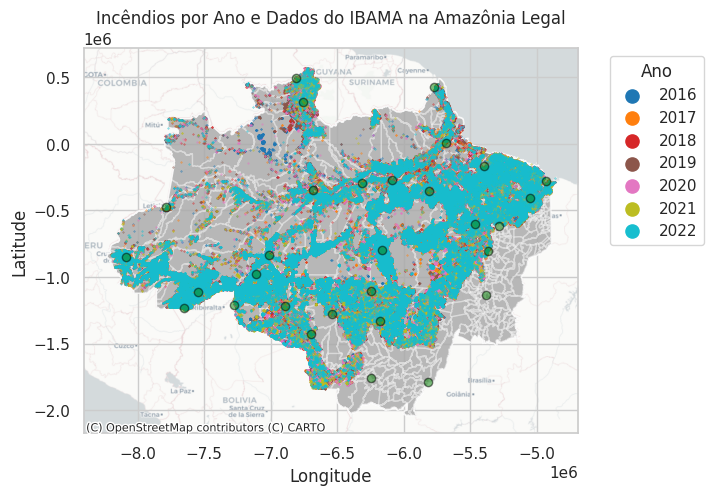

In [ ]:
# Reprojetar para o sistema de coordenadas EPSG:3857
limites = limites.to_crs(epsg=3857)
muni = muni.to_crs(epsg=3857)
incendio_gdf = incendio_gdf.to_crs(epsg=3857)
ibama_amazonia_legal = ibama_amazonia_legal.to_crs(epsg=3857)

# Obter os anos únicos da coluna "ANO" no DataFrame de incêndios
anos_unicos = incendio_gdf['ANO'].unique()

# Criar um mapa de cores para os anos
cmap = plt.get_cmap("tab10", len(anos_unicos))

fig, ax = plt.subplots(figsize=(10, 5))

limites.plot(ax=ax, color='grey', alpha=0.8)
muni.plot(ax=ax, color='white', alpha=0.3)


# Plotar os incêndios para cada ano com cores diferentes
for i, ano in enumerate(sorted(anos_unicos)):
    # Filtrar os dados de incêndios para o ano atual
    incendio_ano = incendio_gdf[incendio_gdf['ANO'] == ano]
    # Plotar os incêndios do ano atual com uma cor específica
    incendio_ano.plot(ax=ax, color=cmap(i), markersize=0.1, label=str(ano))  # Ajuste o markersize conforme necessário

# Plotar os dados do IBAMA na Amazônia Legal
ibama_amazonia_legal.plot(ax=ax, color='green', alpha=0.5, edgecolor='black')
ctx.add_basemap(ax, crs=limites.crs.to_string(), source=ctx.providers.CartoDB.Positron)

plt.title("Incêndios por Ano e Dados do IBAMA na Amazônia Legal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left', scatterpoints=1, markerscale=30)
plt.show()



In [ ]:
# Reprojetar para o sistema de coordenadas EPSG:3857
limites = limites.to_crs(epsg=3857)
muni = muni.to_crs(epsg=3857)
incendio_gdf = incendio_gdf.to_crs(epsg=3857)
ibama_amazonia_legal = ibama_amazonia_legal.to_crs(epsg=3857)

# Obter os anos únicos da coluna "ANO" no DataFrame de incêndios
anos_unicos = sorted(incendio_gdf['ANO'].unique())

# Criar a função de plotagem que será chamada pelo slider
def plot_incendios_por_ano(ano):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plotar os limites e o município
    limites.plot(ax=ax, color='grey', alpha=0.8)
    muni.plot(ax=ax, color='white', alpha=0.3)

    # Filtrar os dados de incêndios para o ano selecionado
    incendio_ano = incendio_gdf[incendio_gdf['ANO'] == ano]
    incendio_ano.plot(ax=ax, color='red', markersize=1, label=str(ano))

    # Plotar os dados do IBAMA na Amazônia Legal
    ibama_amazonia_legal.plot(ax=ax, color='green', alpha=0.5, edgecolor='black')

    ctx.add_basemap(ax, crs=limites.crs, source=ctx.providers.CartoDB.Positron)

    plt.title(f"Incêndios no Ano {ano} e Dados do IBAMA na Amazônia Legal")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

# Criar o slider de anos
interact(plot_incendios_por_ano, ano=IntSlider(min=anos_unicos[0], max=anos_unicos[-1], step=1, value=anos_unicos[0]))


interactive(children=(IntSlider(value=2016, description='ano', max=2022, min=2016), Output()), _dom_classes=('…

<function __main__.plot_incendios_por_ano(ano)>

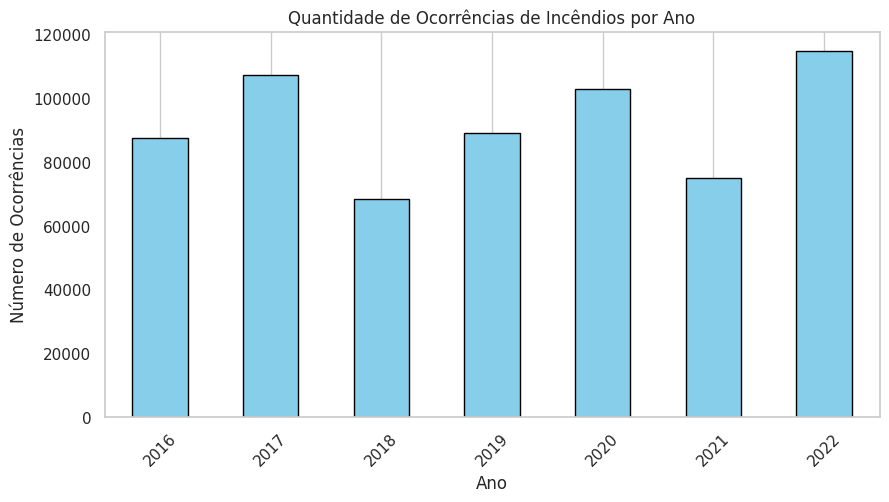

In [ ]:
# Contar a quantidade de ocorrências por ano
ocorrencias_por_ano = incendio_gdf['ANO'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ocorrencias_por_ano.plot(kind='bar', color='skyblue', edgecolor='black')

# Configurar título e rótulos
plt.title("Quantidade de Ocorrências de Incêndios por Ano")
plt.xlabel("Ano")
plt.ylabel("Número de Ocorrências")
plt.grid(axis='y')

# Mostrar o gráfico
plt.xticks(rotation=45)
plt.show()


In [ ]:
desmat['VIEW_DATE'] = pd.to_datetime(desmat['VIEW_DATE'], errors='coerce')
desmat['ANO'] = desmat['VIEW_DATE'].dt.year

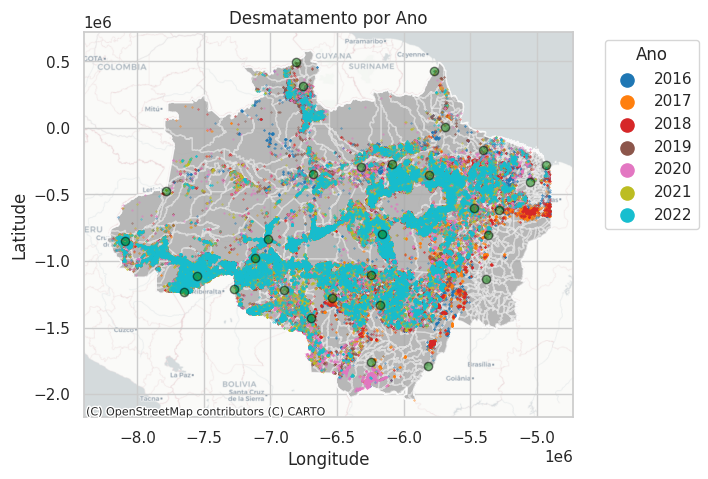

In [ ]:
# Reprojetar para o sistema de coordenadas EPSG:3857
limites = limites.to_crs(epsg=3857)
muni = muni.to_crs(epsg=3857)
desmat = desmat.to_crs(epsg=3857)
ibama_amazonia_legal = ibama_amazonia_legal.to_crs(epsg=3857)

# Atualizar o centroide após reprojetar para EPSG:3857
desmat['centroid'] = desmat.geometry.centroid

fig, ax = plt.subplots(figsize=(10, 5))
limites.plot(ax=ax, color='grey', alpha=0.8)
muni.plot(ax=ax, color='white', alpha=0.3)

# Plotar o desmatamento para cada ano com pontos centrais
for i, ano in enumerate(sorted(anos_unicos)):
    desmat_ano = desmat[desmat['ANO'] == ano]
    desmat_ano.set_geometry('centroid').plot(ax=ax, color=cmap(i), markersize=0.1, label=str(ano))

# Plotar os dados do IBAMA na Amazônia Legal
ibama_amazonia_legal.plot(ax=ax, color='green', alpha=0.5, edgecolor='black')
ctx.add_basemap(ax, crs=limites.crs, source=ctx.providers.CartoDB.Positron)

plt.title("Desmatamento por Ano")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left', scatterpoints=1, markerscale=30)

plt.show()


In [ ]:
# Reprojetar para o sistema de coordenadas EPSG:3857
limites = limites.to_crs(epsg=3857)
muni = muni.to_crs(epsg=3857)
desmat = desmat.to_crs(epsg=3857)
ibama_amazonia_legal = ibama_amazonia_legal.to_crs(epsg=3857)

desmat['centroid'] = desmat.geometry.centroid

# Obter os anos únicos da coluna "ANO" no DataFrame de desmatamento
anos_unicos = sorted(desmat['ANO'].unique())

# Criar a função de plotagem que será chamada pelo slider
def plot_desmatamento_por_ano(ano):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plotar os limites e o município
    limites.plot(ax=ax, color='grey', alpha=0.8)
    muni.plot(ax=ax, color='white', alpha=0.3)

    # Filtrar os dados de desmatamento para o ano selecionado
    desmat_ano = desmat[desmat['ANO'] == ano]
    desmat_ano.set_geometry('centroid').plot(ax=ax, color='blue', markersize=1, label=str(ano))

    # Plotar os dados do IBAMA na Amazônia Legal
    ibama_amazonia_legal.plot(ax=ax, color='green', alpha=0.5, edgecolor='black')

    # Adicionar o mapa de fundo
    ctx.add_basemap(ax, crs=limites.crs, source=ctx.providers.CartoDB.Positron)

    # Configurar título e rótulos
    plt.title(f"Desmatamento no Ano {ano}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Mostrar o gráfico
    plt.show()

interact(plot_desmatamento_por_ano, ano=IntSlider(min=anos_unicos[0], max=anos_unicos[-1], step=1, value=anos_unicos[0]))


interactive(children=(IntSlider(value=2016, description='ano', max=2024, min=2016), Output()), _dom_classes=('…

<function __main__.plot_desmatamento_por_ano(ano)>

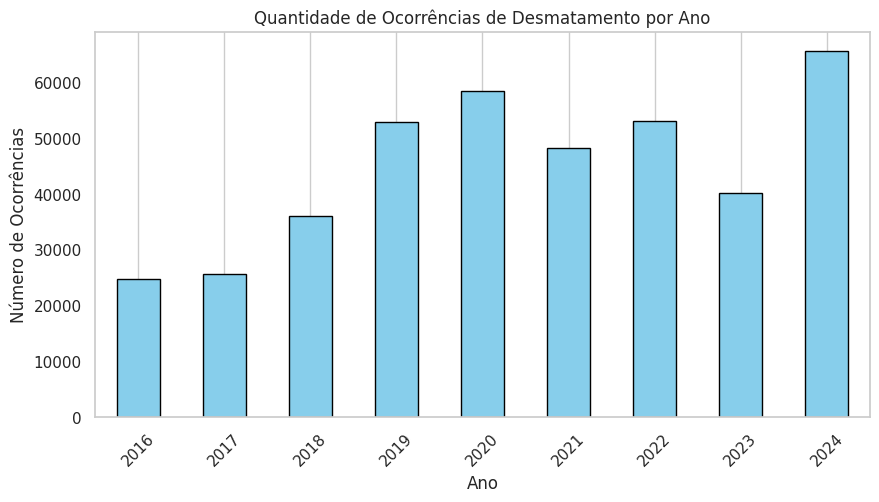

In [ ]:
# Extrair o ano da coluna VIEW_DATE e contar as ocorrências por ano
desmat['ANO'] = desmat['VIEW_DATE'].dt.year
ocorrencias_por_ano = desmat['ANO'].value_counts().sort_index()

# Criar o gráfico
plt.figure(figsize=(10, 5))
ocorrencias_por_ano.plot(kind='bar', color='skyblue', edgecolor='black')

# Configurar título e rótulos
plt.title("Quantidade de Ocorrências de Desmatamento por Ano")
plt.xlabel("Ano")
plt.ylabel("Número de Ocorrências")

# Adicionar grade
plt.grid(axis='y')

# Mostrar o gráfico
plt.xticks(rotation=45)
plt.show()


## Considerações finais

## Vamos dividir o mapa da Amazônia legal em quadrantes e analisá-los individualmente.

In [ ]:
limites = limites.to_crs(epsg=4674)
muni = muni.to_crs(epsg=4674)
desmat = desmat.to_crs(epsg=4674)
ibama_amazonia_legal = ibama_amazonia_legal.to_crs(epsg=4674)
incendio_gdf = incendio_gdf.to_crs(epsg=4674)

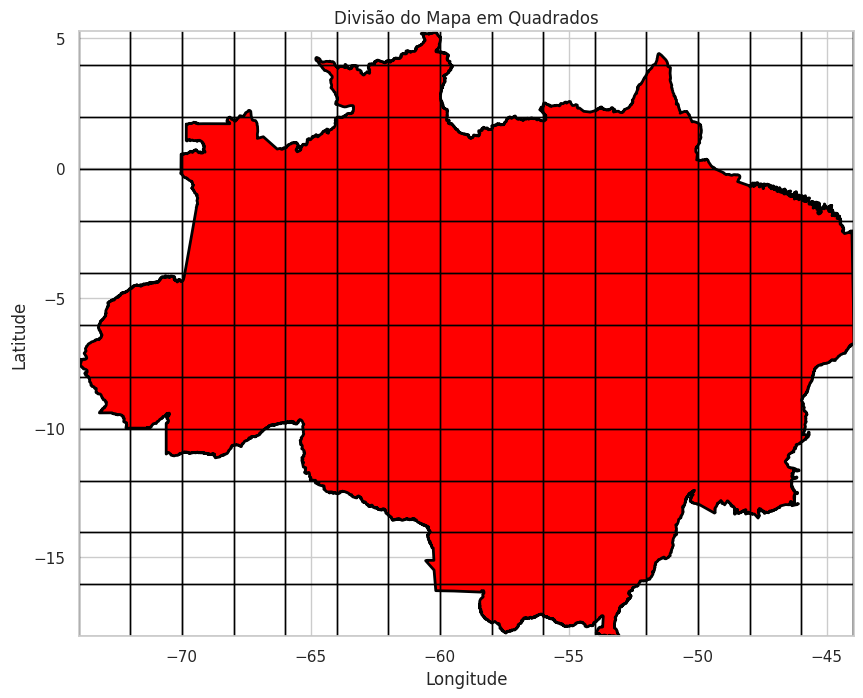

In [ ]:
# Define o tamanho do quadrado (em unidades do sistema de coordenadas)
grid_size = 2  # Ajuste conforme necessário

# Obter os limites da área
minx, miny, maxx, maxy = limites.total_bounds

# Criar uma grade de quadrados
x_points = np.arange(minx, maxx, grid_size)
y_points = np.arange(miny, maxy, grid_size)

# Criar os polígonos da grade
polygons = [box(x0, y0, x0 + grid_size, y0 + grid_size) for x0 in x_points for y0 in y_points]

# Converter os polígonos em um GeoDataFrame
grid = gpd.GeoDataFrame(geometry=polygons, crs=limites.crs)

# Configurar o plot
fig, ax = plt.subplots(figsize=(10, 10))
limites.plot(ax=ax, color='red', edgecolor='black', linewidth=2)
grid.plot(ax=ax, edgecolor='black', facecolor='none')

plt.title("Divisão do Mapa em Quadrados")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(minx, maxx)
plt.ylim(miny, maxy)
plt.grid(True)
plt.show()


<ipython-input-30-a07e03d79557>:18: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4674
Right CRS: None

  counts = gpd.sjoin(grid, dados, how="left", predicate="intersects")


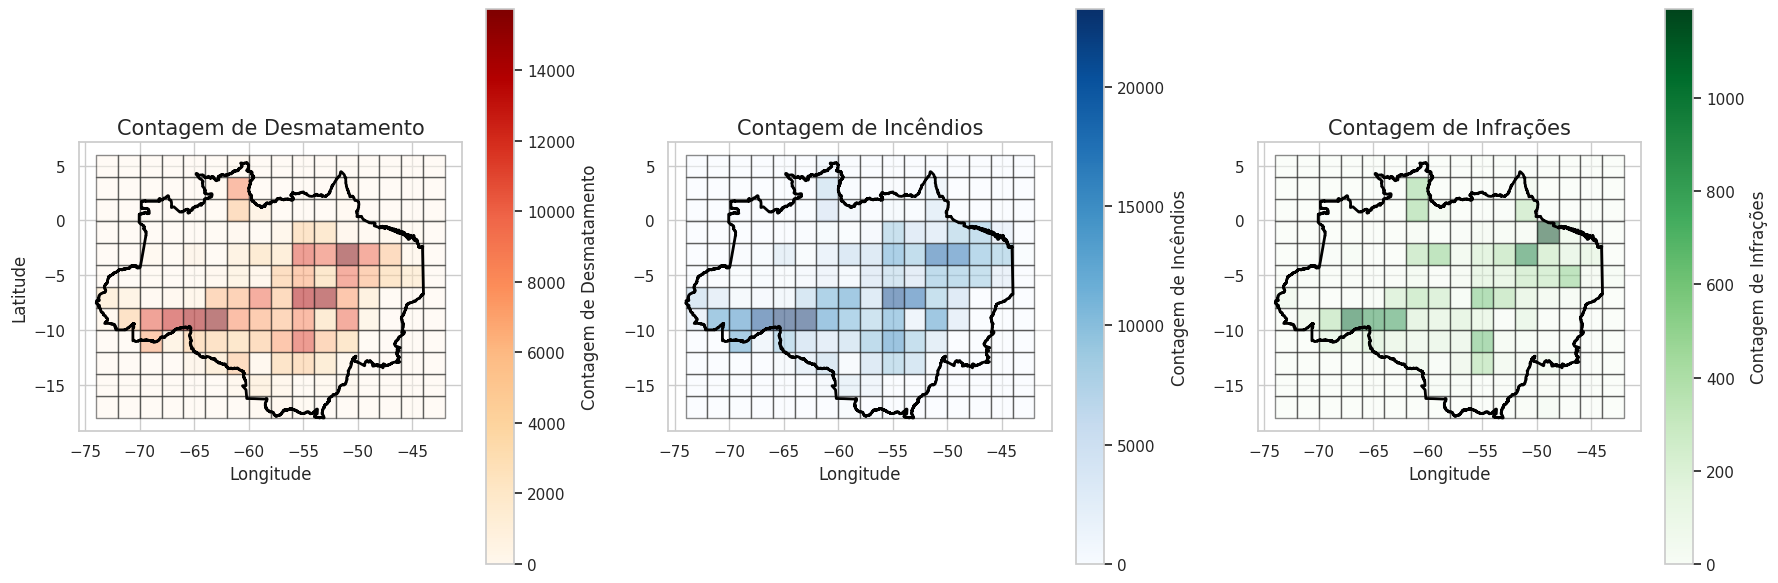

In [ ]:
grid_size = 2  # Ajuste conforme necessário

# Obter os limites da área
minx, miny, maxx, maxy = limites.total_bounds

# Criar uma grade de quadrados
x_points = np.arange(minx, maxx, grid_size)
y_points = np.arange(miny, maxy, grid_size)

# Criar os polígonos da grade
polygons = [box(x0, y0, x0 + grid_size, y0 + grid_size) for x0 in x_points for y0 in y_points]

# Converter os polígonos em um GeoDataFrame
grid = gpd.GeoDataFrame(geometry=polygons, crs=limites.crs)

# Função para contar ocorrências em cada quadrado
def contar_ocorrencias(grid, dados):
    counts = gpd.sjoin(grid, dados, how="left", predicate="intersects")
    counts = counts.groupby(counts.index).size().reset_index(name='count')
    grid['count'] = counts['count'] if not counts.empty else 0
    return grid

# Contar desmatamento
grid_desmatamento = contar_ocorrencias(grid.copy(), desmat)

# Contar incêndios
grid_incendio = contar_ocorrencias(grid.copy(), incendio_gdf)

# Contar infrações
grid_infracoes = contar_ocorrencias(grid.copy(), infracoes_gpd)

# Criar uma base de dados final combinando as contagens
final_data = pd.DataFrame({
    'xmin': grid.geometry.bounds['minx'],
    'ymin': grid.geometry.bounds['miny'],
    'xmax': grid.geometry.bounds['maxx'],
    'ymax': grid.geometry.bounds['maxy'],
    'desmatamento_count': grid_desmatamento['count'],
    'incendio_count': grid_incendio['count'],
    'infracao_count': grid_infracoes['count']
})

# Criar polígonos a partir dos valores xmin, ymin, xmax, ymax
final_polygons = [box(row['xmin'], row['ymin'], row['xmax'], row['ymax']) for index, row in final_data.iterrows()]
final_gdf = gpd.GeoDataFrame(final_data, geometry=final_polygons, crs=limites.crs)

# Plotar os dados em gráficos separados
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico de desmatamento
ax[0].set_title('Contagem de Desmatamento', fontsize=15)
limites.boundary.plot(ax=ax[0], color='black', linewidth=2)
final_gdf.plot(column='desmatamento_count', ax=ax[0], cmap='OrRd', edgecolor='k', alpha=0.5,
                legend=True,
                legend_kwds={'label': "Contagem de Desmatamento"},
                vmin=0, vmax=final_data['desmatamento_count'].max() * 0.8)  # Ajuste de escala

ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

# Gráfico de incêndios
ax[1].set_title('Contagem de Incêndios', fontsize=15)
limites.boundary.plot(ax=ax[1], color='black', linewidth=2)
final_gdf.plot(column='incendio_count', ax=ax[1], cmap='Blues', edgecolor='k', alpha=0.5,
                legend=True,
                legend_kwds={'label': "Contagem de Incêndios"},
                vmin=0, vmax=final_data['incendio_count'].max() * 0.8)  # Ajuste de escala
ax[1].set_xlabel('Longitude')

# Gráfico de infrações
ax[2].set_title('Contagem de Infrações', fontsize=15)
limites.boundary.plot(ax=ax[2], color='black', linewidth=2)
final_gdf.plot(column='infracao_count', ax=ax[2], cmap='Greens', edgecolor='k', alpha=0.5,
                legend=True,
                legend_kwds={'label': "Contagem de Infrações"},
                vmin=0, vmax=final_data['infracao_count'].max() * 0.8)  # Ajuste de escala
ax[2].set_xlabel('Longitude')


plt.tight_layout()
plt.show()





In [ ]:
# Criar a matriz de pesos espaciais usando a vizinhança de K-vizinhos (por exemplo, 5 vizinhos mais próximos)
w = ps.weights.KNN.from_dataframe(final_gdf, k=5)
w.transform = 'r'  # Normalizar os pesos

# Calcular o Índice de Moran para cada variável

# 1. Índice de Moran para desmatamento
moran_desmatamento = Moran(final_gdf['desmatamento_count'], w)
print("Índice de Moran para Desmatamento:", moran_desmatamento.I)

# 2. Índice de Moran para incêndios
moran_incendio = Moran(final_gdf['incendio_count'], w)
print("Índice de Moran para Incêndios:", moran_incendio.I)


Índice de Moran para Desmatamento: 0.5634518700924206
Índice de Moran para Incêndios: 0.5588974639894939


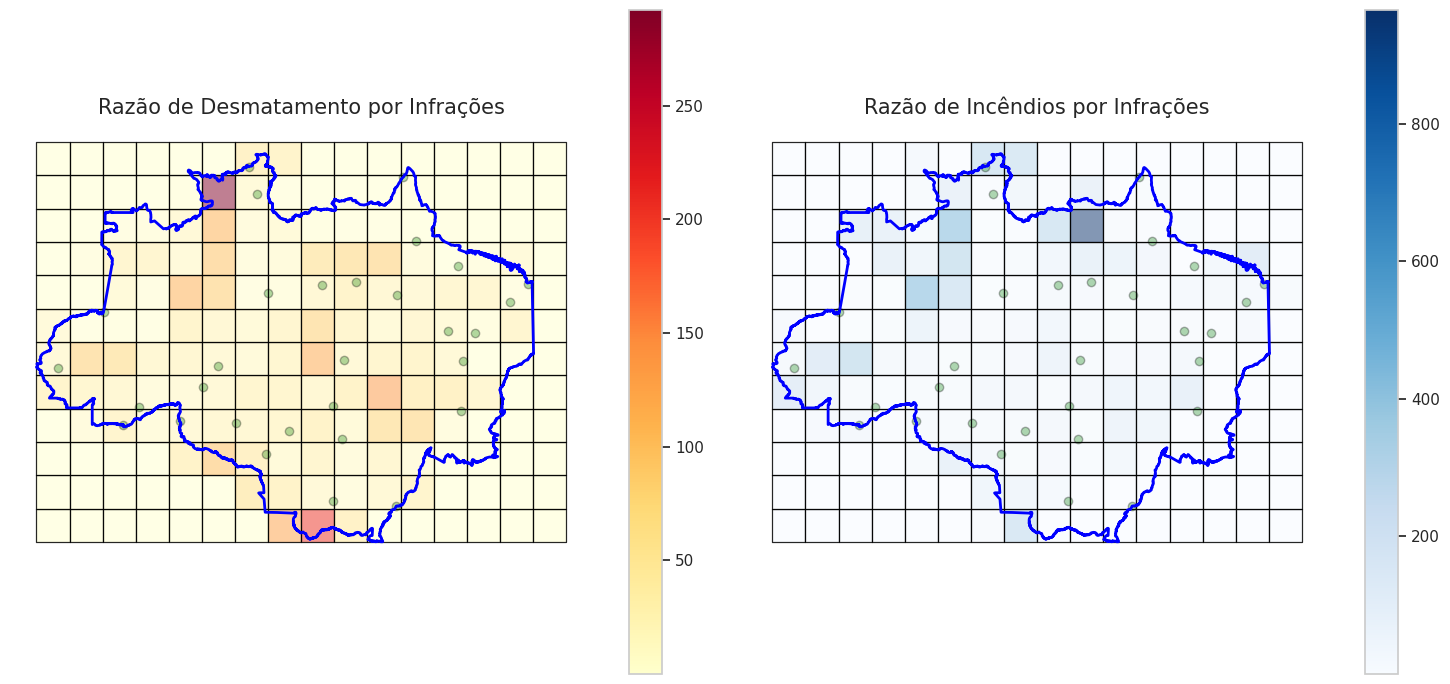

In [ ]:
final_data['razao_desmatamento_infracoes'] = np.where(
    final_data['infracao_count'] > 0,
    final_data['desmatamento_count'] / final_data['infracao_count'],
    np.nan)

# Calcular a razão de incêndios por infrações
final_data['razao_incendios_infracoes'] = np.where(
    final_data['infracao_count'] > 0,
    final_data['incendio_count'] / final_data['infracao_count'],
    np.nan)

# Atualizar o GeoDataFrame com a nova coluna
final_gdf['razao_desmatamento_infracoes'] = final_data['razao_desmatamento_infracoes']
final_gdf['razao_incendios_infracoes'] = final_data['razao_incendios_infracoes']

# Plotar a razão de desmatamento para infrações
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Mapa da razão de desmatamento por infrações
final_gdf.boundary.plot(ax=ax[0], color='black', linewidth=0.5)  # Limites da grade
final_gdf.plot(column='razao_desmatamento_infracoes', ax=ax[0], legend=True,
                cmap='YlOrRd', edgecolor='black', alpha=0.5)

# Plotar o polígono do IBAMA e os limites
ibama_amazonia_legal.plot(ax=ax[0], color='green', alpha=0.3, edgecolor='black')
limites.boundary.plot(ax=ax[0], color='blue', linewidth=2)

ax[0].set_title('Razão de Desmatamento por Infrações', fontsize=15)
ax[0].set_axis_off()

# Mapa da razão de incêndios por infrações
final_gdf.boundary.plot(ax=ax[1], color='black', linewidth=0.5)  # Limites da grade
final_gdf.plot(column='razao_incendios_infracoes', ax=ax[1], legend=True,
                cmap='Blues', edgecolor='black', alpha=0.5)

# Plotar o polígono do IBAMA e os limites
ibama_amazonia_legal.plot(ax=ax[1], color='green', alpha=0.3, edgecolor='black')
limites.boundary.plot(ax=ax[1], color='blue', linewidth=2)

ax[1].set_title('Razão de Incêndios por Infrações', fontsize=15)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()


In [ ]:
from shapely.geometry import Point
from scipy.spatial import cKDTree

final_gdf = final_gdf.to_crs("EPSG:31981")
ibama_amazonia_legal = ibama_amazonia_legal.to_crs("EPSG:31981")

# Converter as geometrias MULTIPOINT para seus centroides
ibama_points = ibama_amazonia_legal.geometry.apply(lambda geom: geom.centroid)

# Extrair coordenadas dos pontos do Ibama (agora são pontos individuais)
ibama_points_coords = np.array(list(zip(ibama_points.x, ibama_points.y)))

# Calcular o centroide de cada célula da grade
grid_centroids = final_gdf.geometry.centroid
grid_centroid_coords = np.array(list(zip(grid_centroids.x, grid_centroids.y)))

# Calcular a distância média dos pontos do Ibama até o centroide de cada célula
tree = cKDTree(ibama_points_coords)
mean_distances = []

for centroid in grid_centroid_coords:
    distances, _ = tree.query(centroid, k=len(ibama_points_coords))  # Calcular todas as distâncias
    mean_distances.append(np.mean(distances))

# Adicionar a coluna de distância média ao final_gdf
final_gdf['mean_distance_ibama'] = mean_distances

# Calcular correlações entre a distância média dos pontos do Ibama e as contagens
correlacao_desmatamento = final_gdf['mean_distance_ibama'].corr(final_gdf['desmatamento_count'])
correlacao_incendio = final_gdf['mean_distance_ibama'].corr(final_gdf['incendio_count'])

print("Correlação entre Distância Média do Ibama e Desmatamento Count:", correlacao_desmatamento)
print("Correlação entre Distância Média do Ibama e Incêndio Count:", correlacao_incendio)


Correlação entre Distância Média do Ibama e Desmatamento Count: -0.5552032893615907
Correlação entre Distância Média do Ibama e Incêndio Count: -0.5333408686753305


### Interpretação dos Valores de Correlação

Os valores de correlação variam entre -1 e 1:
- **+1**: Correlação positiva perfeita (à medida que uma variável aumenta, a outra também aumenta).
- **0**: Nenhuma correlação linear (as variáveis não têm uma relação linear clara).
- **-1**: Correlação negativa perfeita (à medida que uma variável aumenta, a outra diminui).

### Interpretação Específica dos Resultados

1. **Correlação entre Distância Média do Ibama e Desmatamento Count: -0.557**
   - Esse valor negativo indica uma **correlação negativa moderada** entre a distância média dos pontos do Ibama e a contagem de desmatamento.
   - Isso significa que, em média, **quanto mais próximos os pontos do Ibama estão de uma célula, menor tende a ser a contagem de desmatamento** nessa célula.
   - Essa relação sugere que a proximidade dos pontos do Ibama pode estar associada a uma **diminuição no desmatamento**, o que pode indicar um efeito dissuasivo na presença dessas unidades.

2. **Correlação entre Distância Média do Ibama e Incêndio Count: -0.536**
   - Também apresenta uma **correlação negativa moderada**.
   - Isso sugere que **células mais próximas dos pontos do Ibama tendem a ter menos incêndios**.
   - Assim como no caso do desmatamento, a presença próxima de pontos do Ibama pode estar associada a uma redução na frequência de incêndios, possivelmente devido ao monitoramento e fiscalização.

### Conclusão Geral

Esses valores indicam que a **proximidade dos pontos do Ibama** tende a estar associada a **menores ocorrências de desmatamento, incêndios e infrações** nas áreas ao redor. Isso pode refletir um efeito de fiscalização e controle ambiental, onde a presença das unidades do Ibama está relacionada com uma menor incidência de atividades ilegais ou prejudiciais ao meio ambiente na Amazônia Legal.

Esses resultados poderiam motivar estudos adicionais sobre a eficácia da distribuição espacial das unidades do Ibama e ajudar a orientar políticas de alocação para melhorar a fiscalização ambiental em áreas críticas.
